In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from my_fun import *
from psychometric_curves import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

In [4]:
# Set parameters
experiment = '2AFC_6'  # Set the experiment (batch)
animals = ['014', '016', '017', '020', '021', '022', '023', '024', '025']

# Analyses of drug data of batch #6

## Psychometric curves

### Probability choose RIGHT

plot_mean_pc took 1.08 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:427: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame(params, columns=columns)], ignore_index=True)


plot_mean_pc took 1.07 seconds to run
plot_mean_pc_drug took 2.22 seconds to run


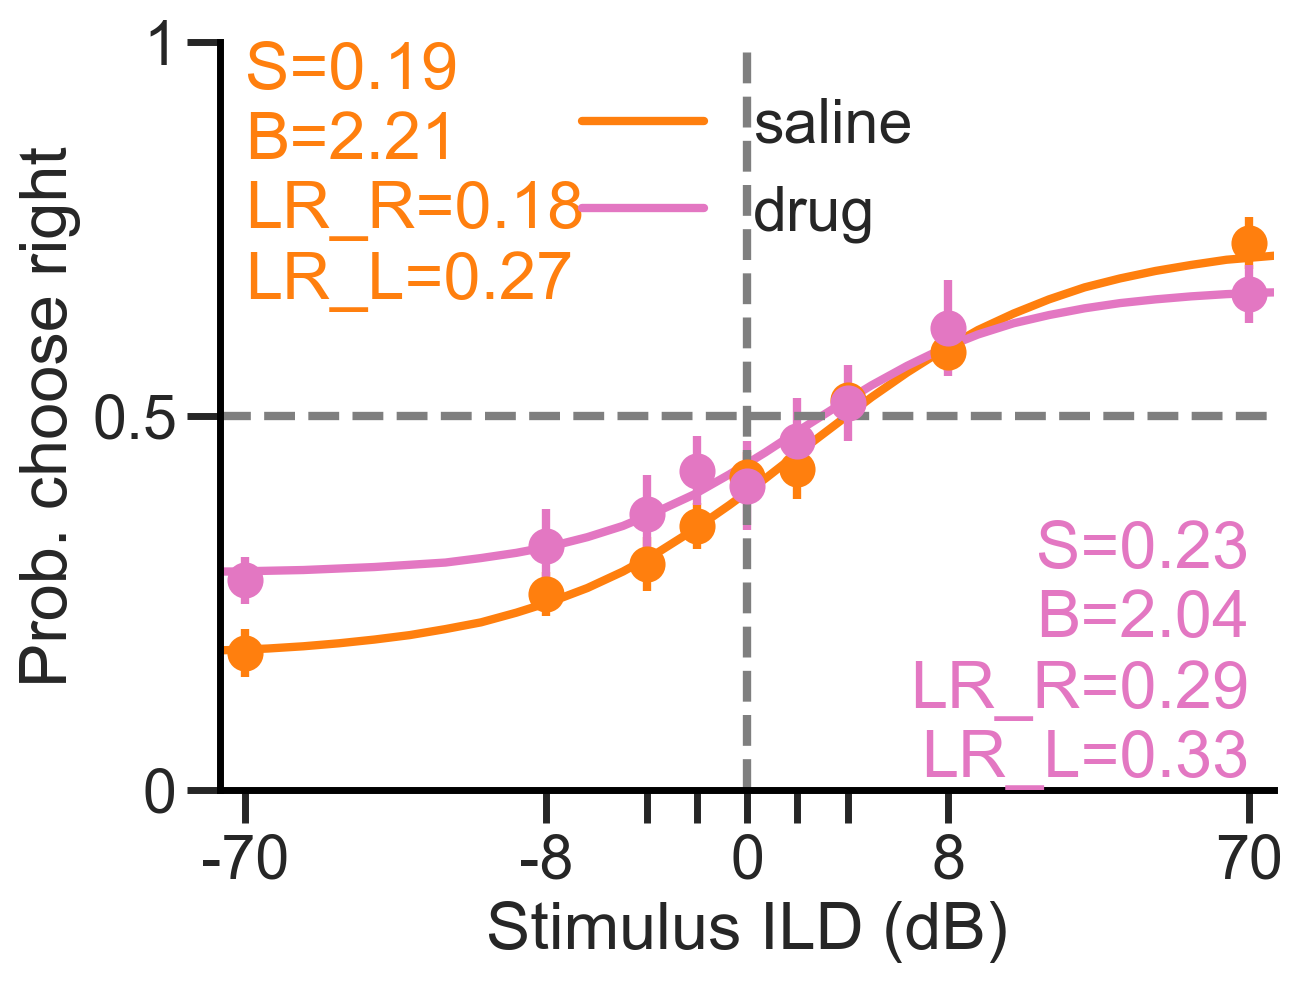

In [5]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind='prob_right')

### Stats

In [7]:
from scipy.stats import ttest_ind

def compare_params(params, param_name):
    """
    Compare the parameters of the saline and drug conditions.
    """

    # Plot seaborn boxplot comparing parameters
    plt.figure(constrained_layout=True)
    sns.boxplot(data=params, x='drug', y=param_name, hue='drug', palette=['tab:gray', 'tab:pink'], linewidth=2.5, showfliers=False, legend=False)
    plt.xticks([0, 1], ['Saline', 'Drug'])
    plt.xlabel('')
    sns.despine()

    saline = params[params['drug'] == 0][param_name]
    drug = params[params['drug'] == 1][param_name]

    t_stat, p_val = ttest_ind(saline, drug)
    print(f"{param_name}: t-statistic = {t_stat:.3f}, p-value = {p_val:.3f}")

    add_star_between(p_val)

sensitivity: t-statistic = -1.150, p-value = 0.267
bias: t-statistic = 0.063, p-value = 0.950
lr_right: t-statistic = -2.257, p-value = 0.038
lr_left: t-statistic = -1.084, p-value = 0.294


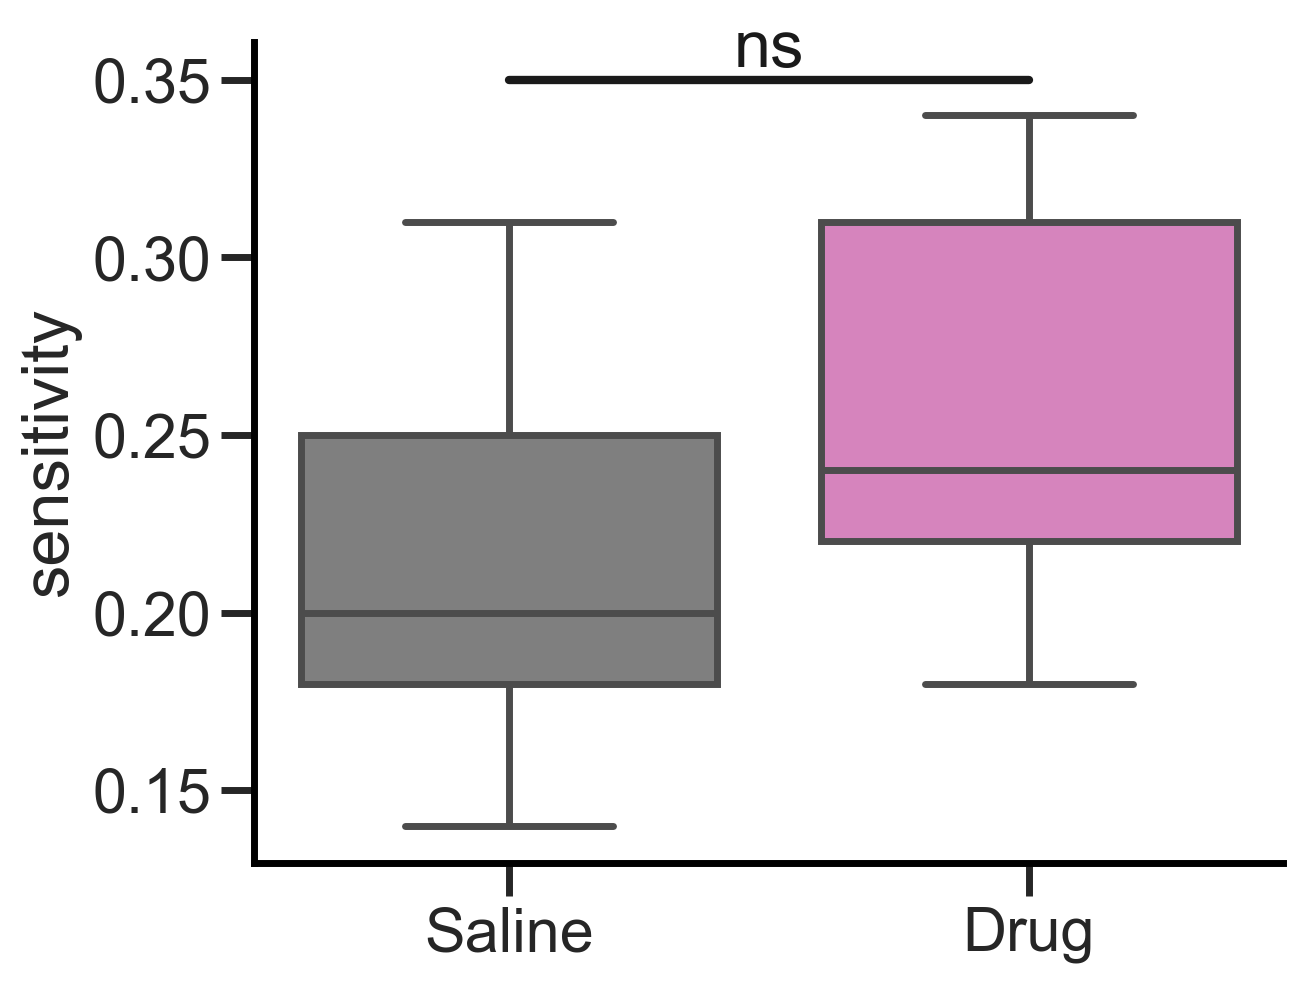

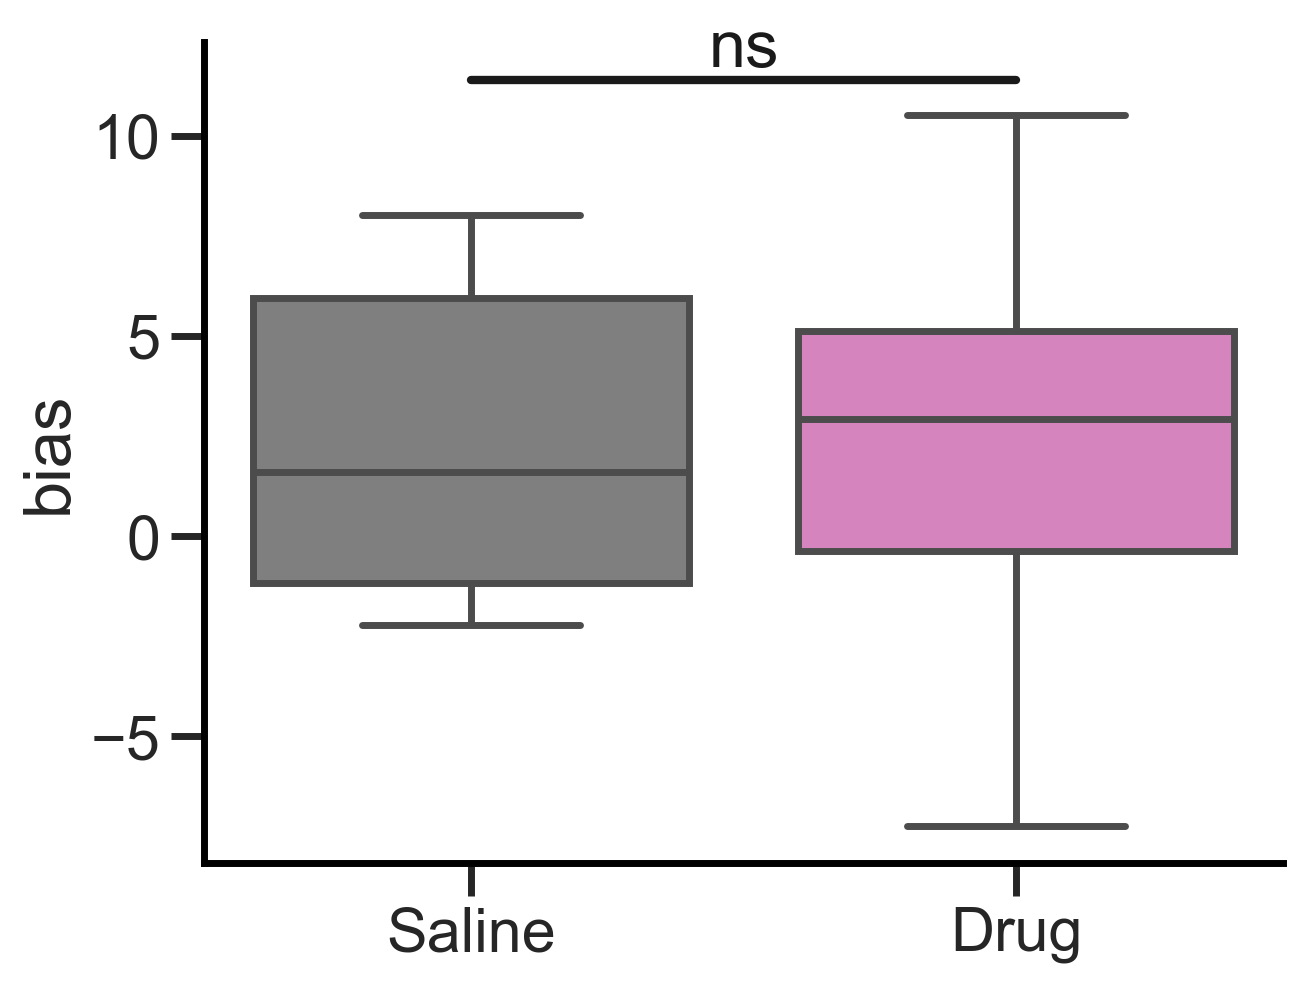

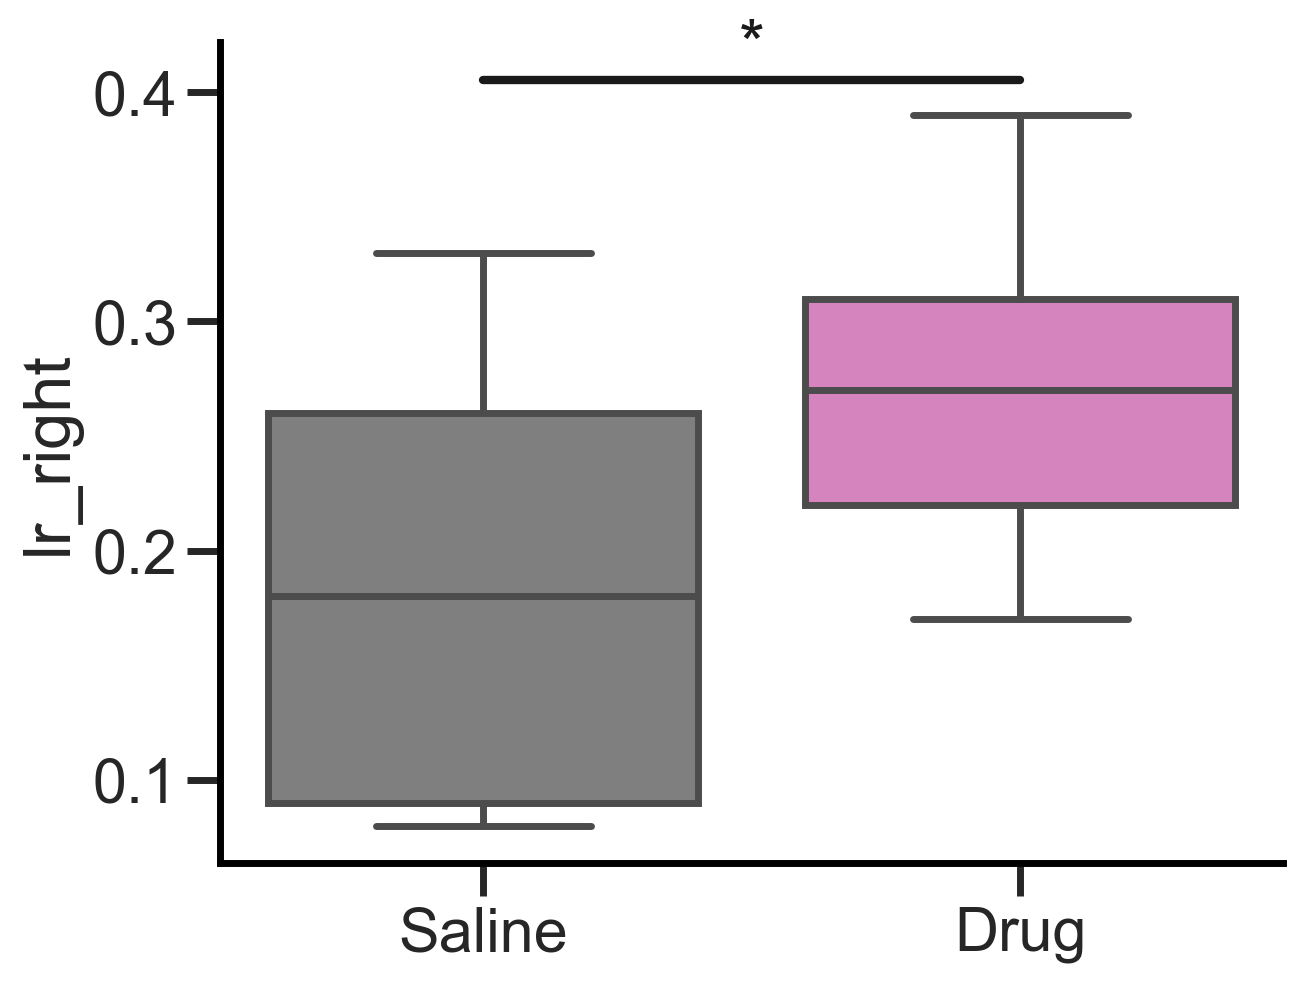

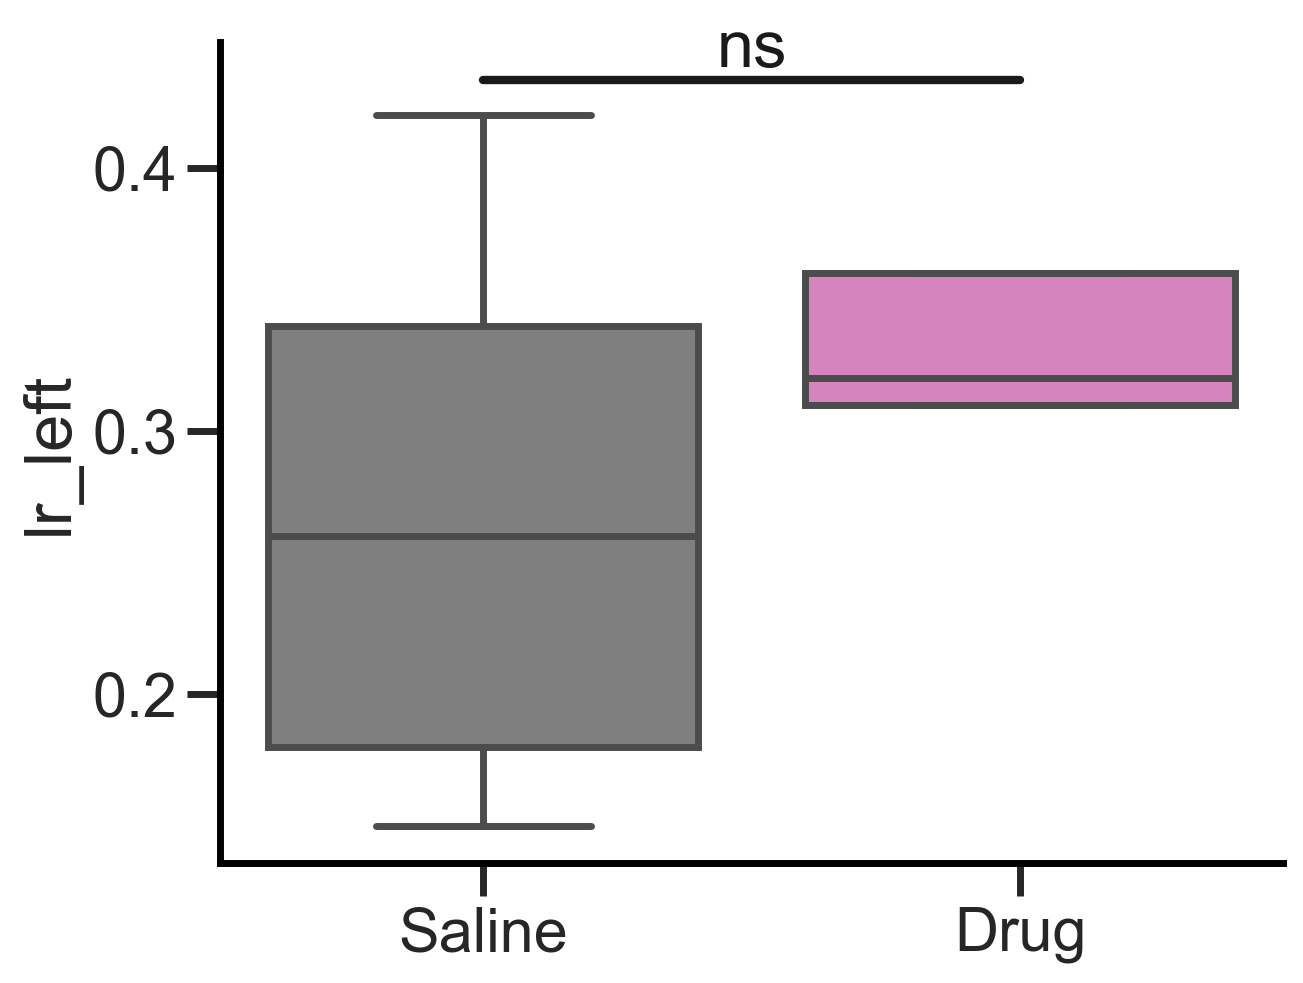

In [8]:
compare_params(params, 'sensitivity')
compare_params(params, 'bias')
compare_params(params, 'lr_right')
compare_params(params, 'lr_left')

### Probability choose REPAT

plot_mean_pc took 1.06 seconds to run


C:\Users\Usuario\PycharmProjects\psychometric_curves\psychometric_curves.py:427: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params = pd.concat([df_params, pd.DataFrame(params, columns=columns)], ignore_index=True)


plot_mean_pc took 1.08 seconds to run
plot_mean_pc_drug took 2.17 seconds to run


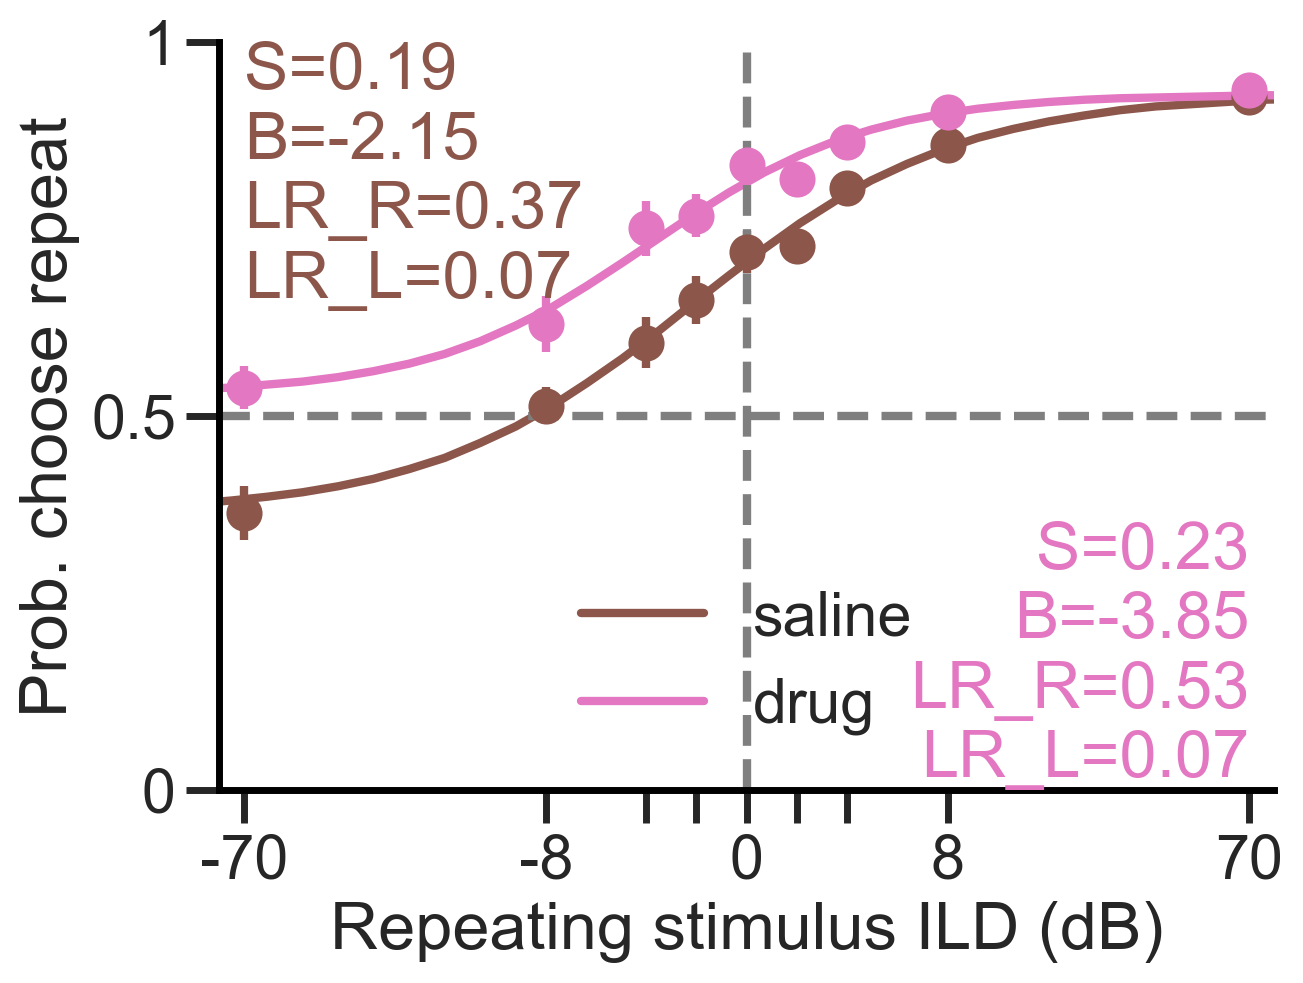

In [9]:
params = plot_mean_pc_drug(experiment='2AFC_6', animals=animals, kind='prob_rep')

sensitivity: t-statistic = -1.894, p-value = 0.077
bias: t-statistic = 1.489, p-value = 0.156
lr_rep: t-statistic = -3.784, p-value = 0.002
lr_alt: t-statistic = -0.400, p-value = 0.695


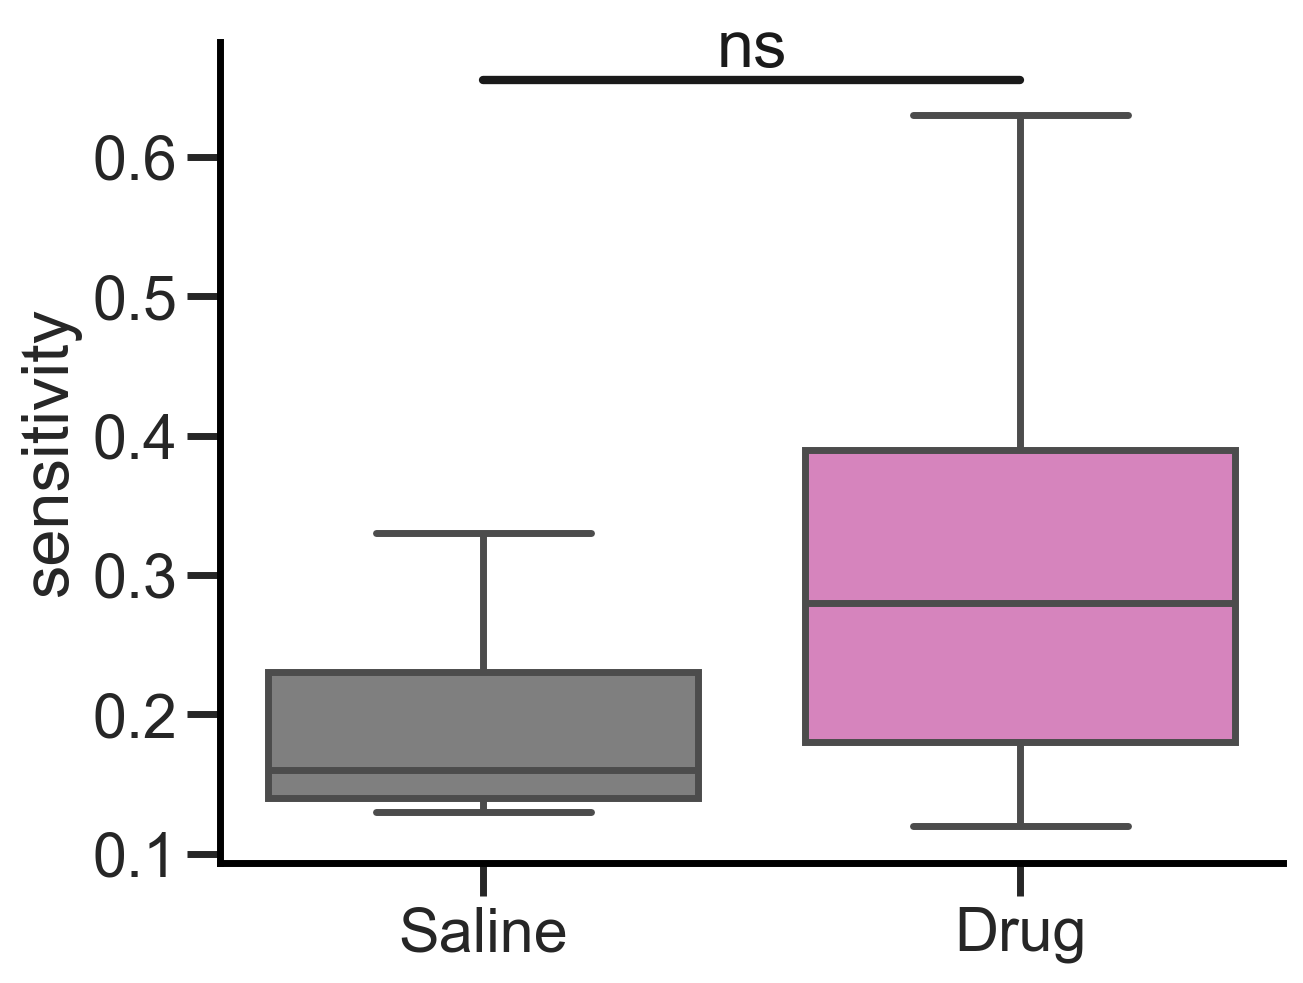

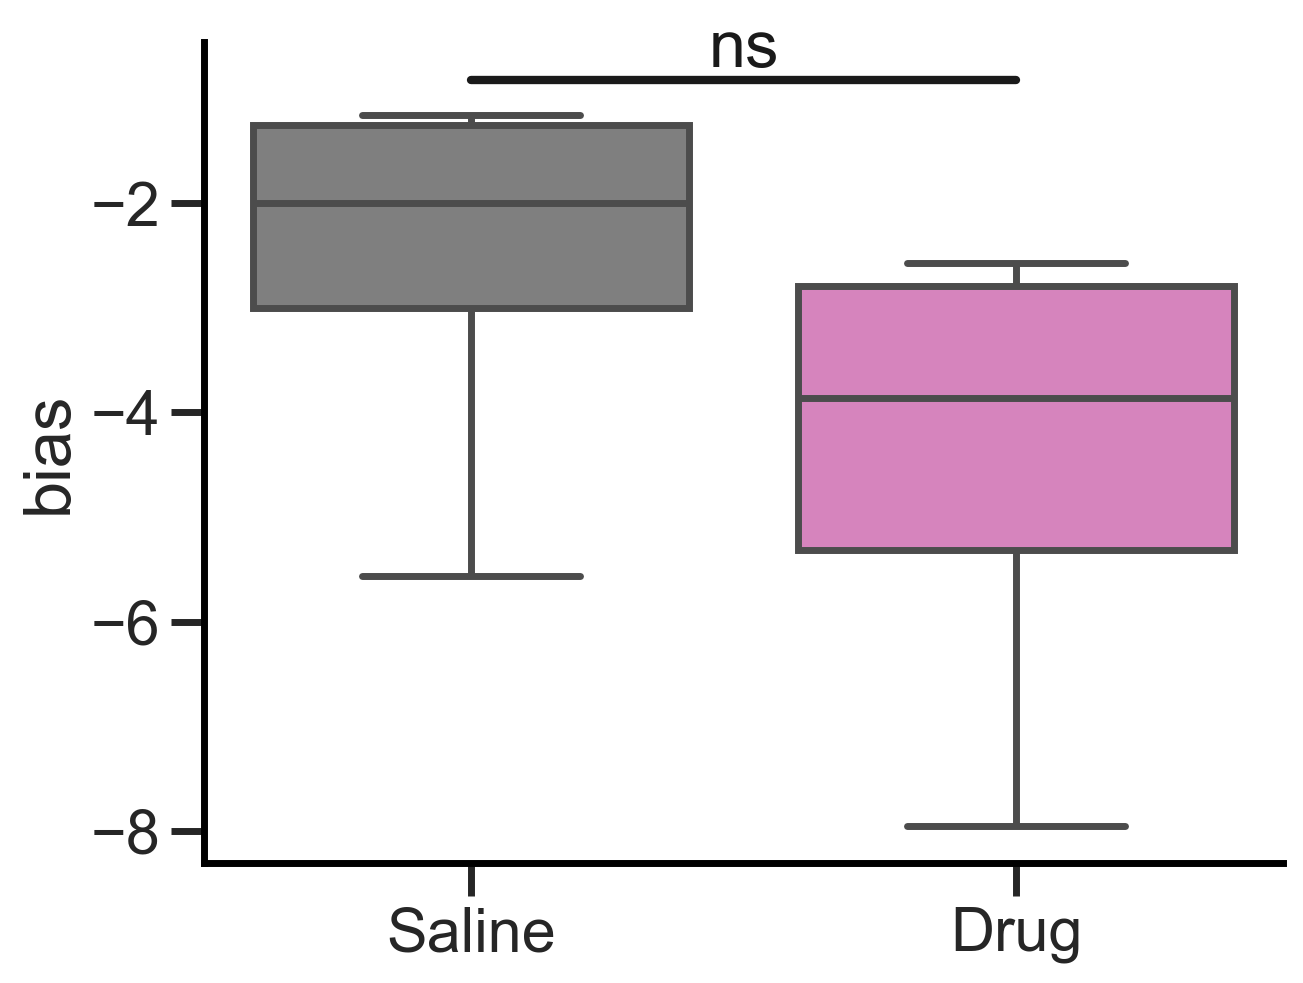

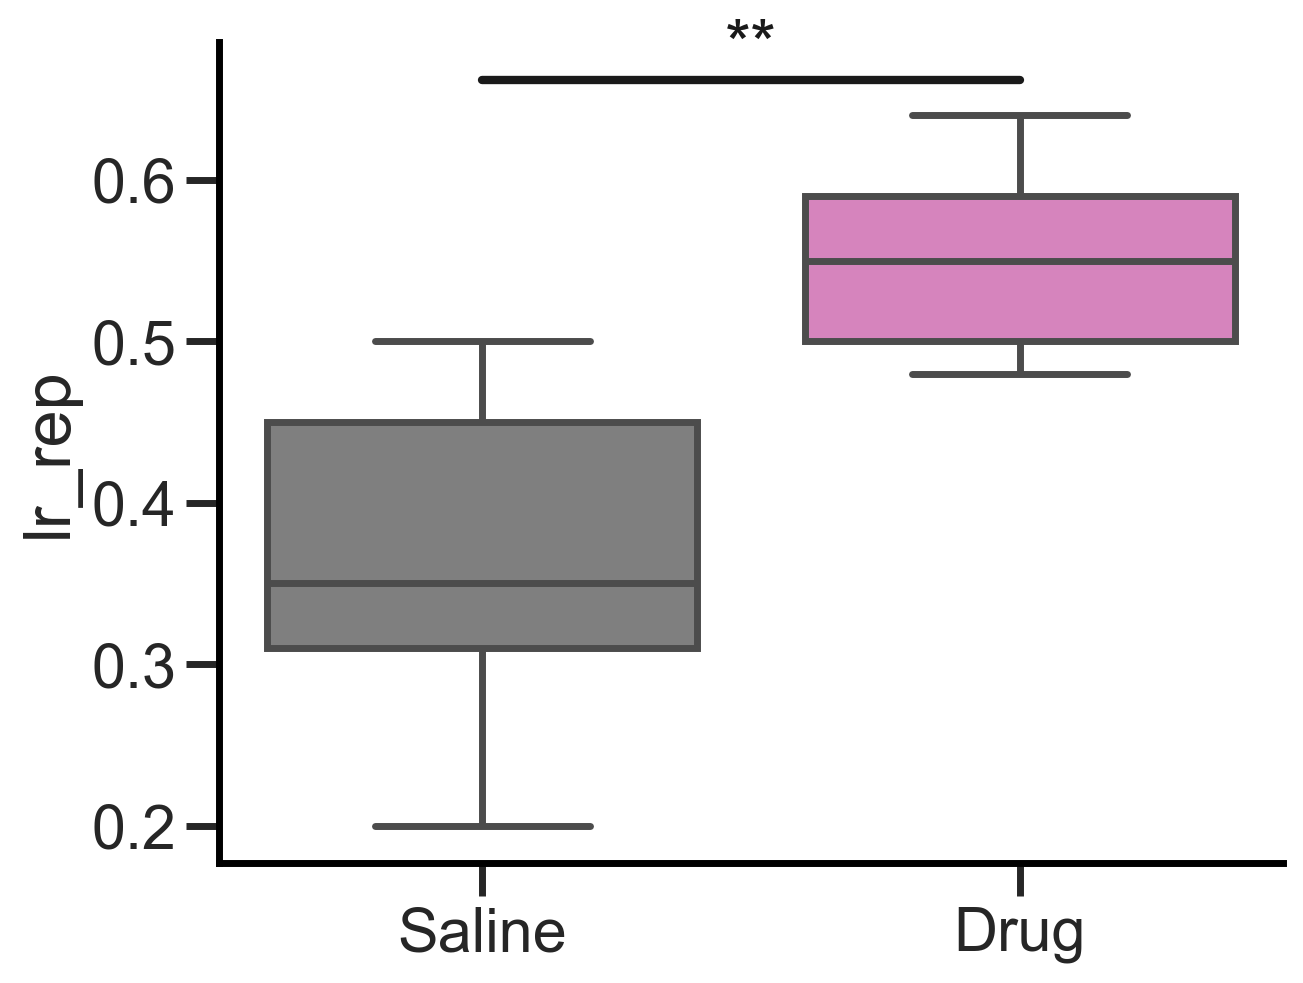

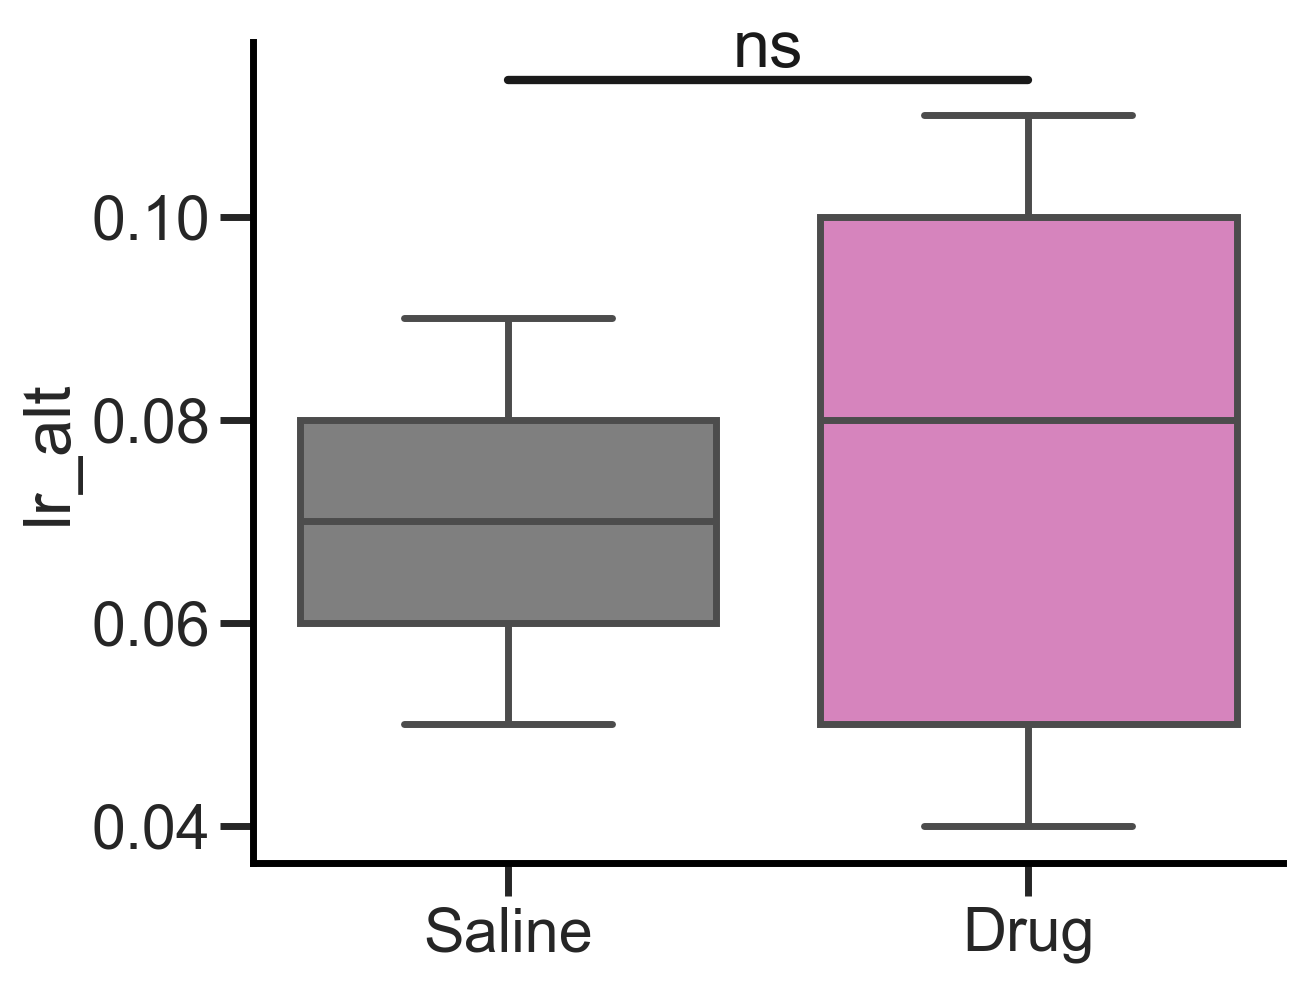

In [10]:
compare_params(params, 'sensitivity')
compare_params(params, 'bias')
compare_params(params, 'lr_rep')
compare_params(params, 'lr_alt')